
Load and Explore the Data




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('energydata_complete.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns.tolist())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (19735, 29)

First 5 rows:
                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        

Data Preprocessing

In [7]:
print("Available columns:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Available columns:
['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2', 'hour', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_morning', 'is_afternoon', 'is_evening', 'is_night', 'Appliances_lag_1', 'Appliances_lag_2', 'Appliances_lag_3', 'Appliances_lag_6', 'Appliances_lag_12', 'Appliances_lag_24', 'Appliances_rolling_mean_3', 'Appliances_rolling_std_3', 'Appliances_rolling_min_3', 'Appliances_rolling_max_3', 'Appliances_rolling_mean_6', 'Appliances_rolling_std_6', 'Appliances_rolling_min_6', 'Appliances_rolling_max_6', 'Appliances_rolling_mean_12', 'Appliances_rolling_std_12', 'Appliances_rolling_min_12', 'Appliances_rolling_max_12', 'Appliances_rolling_mean_24', 'Appliances_rolling_std_24', 'Appliances_

In [10]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    print("Step 1: Date converted to index")
elif pd.api.types.is_datetime64_any_dtype(df.index):
    print("Step 1: Date already set as index")
else:
    df.index = pd.to_datetime(df.index)
    print("Step 1: Index converted to datetime")
df = df.interpolate(method='time')
df = df.fillna(method='ffill').fillna(method='bfill')
print("Step 2: Missing values handled")
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['day_of_month'] = df.index.day
df['month'] = df.index.month
df['week_of_year'] = df.index.isocalendar().week
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_morning'] = ((df['hour'] >= 6) & (df['hour'] < 12)).astype(int)
df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] < 18)).astype(int)
df['is_evening'] = ((df['hour'] >= 18) & (df['hour'] < 22)).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] < 6)).astype(int)
print("Step 3: Temporal features created")
print(f"Features after temporal engineering: {df.shape[1]}")
target_col = 'Appliances'
for lag in [1, 2, 3, 6, 12, 24]:
    df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
for window in [3, 6, 12, 24]:
    df[f'{target_col}_rolling_mean_{window}'] = df[target_col].rolling(window=window).mean()
    df[f'{target_col}_rolling_std_{window}'] = df[target_col].rolling(window=window).std()
    df[f'{target_col}_rolling_min_{window}'] = df[target_col].rolling(window=window).min()
    df[f'{target_col}_rolling_max_{window}'] = df[target_col].rolling(window=window).max()
df = df.dropna()
print("Step 4: Lag and rolling features created")
print(f"Features after lag engineering: {df.shape[1]}")
print(f"Samples after removing NaN: {df.shape[0]}")
if 'T1' in df.columns and 'RH_1' in df.columns:
    df['T1_x_RH1'] = df['T1'] * df['RH_1']
if 'T_out' in df.columns and 'RH_out' in df.columns:
    df['Tout_x_RHout'] = df['T_out'] * df['RH_out']
print("Step 5: Interaction features created")
print(f"Total features: {df.shape[1]}")

Step 1: Date already set as index
Step 2: Missing values handled
Step 3: Temporal features created
Features after temporal engineering: 68
Step 4: Lag and rolling features created
Features after lag engineering: 68
Samples after removing NaN: 19663
Step 5: Interaction features created
Total features: 68


Remove Outliers

In [12]:
def remove_outliers_iqr(data, column, threshold=3.0):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
original_size = len(df)
df = remove_outliers_iqr(df, 'Appliances', threshold=3.0)
removed = original_size - len(df)
print(f"Step 6: Outliers removed ")
print(f"Samples removed: {removed} ({removed/original_size*100:.2f}%)")
print(f"Final dataset size: {df.shape}")

Step 6: Outliers removed 
Samples removed: 313 (1.73%)
Final dataset size: (17828, 68)


Prepare Train/Test Split

In [13]:
X = df.drop(columns=['Appliances'])
y = df['Appliances']
print("\nDataset prepared:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
print("Step 7: Data scaled and split ")


Dataset prepared:
Features (X): (17828, 67)
Target (y): (17828,)

Train set: 12479 samples
Validation set: 1783 samples
Test set: 3566 samples
Step 7: Data scaled and split 


Train Models

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10,
                                          min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                           min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                           random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=6,
                             num_leaves=31, min_child_samples=20, subsample=0.8,
                             colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
}
print("\nTraining models...")
print("="*60)
trained_models = {}
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f" {name} trained successfully!")
print("\n" + "="*60)
print("All models trained!")


Training models...

Training Linear Regression...
 Linear Regression trained successfully!

Training Random Forest...
 Random Forest trained successfully!

Training XGBoost...
 XGBoost trained successfully!

Training LightGBM...
 LightGBM trained successfully!

All models trained!


 Evaluate Models

In [15]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'MAPE': mape
    })
    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE', ascending=True).reset_index(drop=True)
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_df.to_string(index=False))


Linear Regression:
  MAE:  0.0000
  RMSE: 0.0000
  R²:   1.0000
  MAPE: 0.00%

Random Forest:
  MAE:  1.8202
  RMSE: 6.5009
  R²:   0.9628
  MAPE: 2.33%

XGBoost:
  MAE:  2.3822
  RMSE: 5.1003
  R²:   0.9771
  MAPE: 3.43%

LightGBM:
  MAE:  2.4721
  RMSE: 4.9533
  R²:   0.9784
  MAPE: 3.55%

MODEL COMPARISON RESULTS
            Model          MAE         RMSE       R2         MAPE
Linear Regression 9.354815e-14 1.202733e-13 1.000000 1.593347e-13
         LightGBM 2.472116e+00 4.953270e+00 0.978399 3.551140e+00
          XGBoost 2.382180e+00 5.100283e+00 0.977098 3.425715e+00
    Random Forest 1.820166e+00 6.500853e+00 0.962792 2.326845e+00


Visualize Results

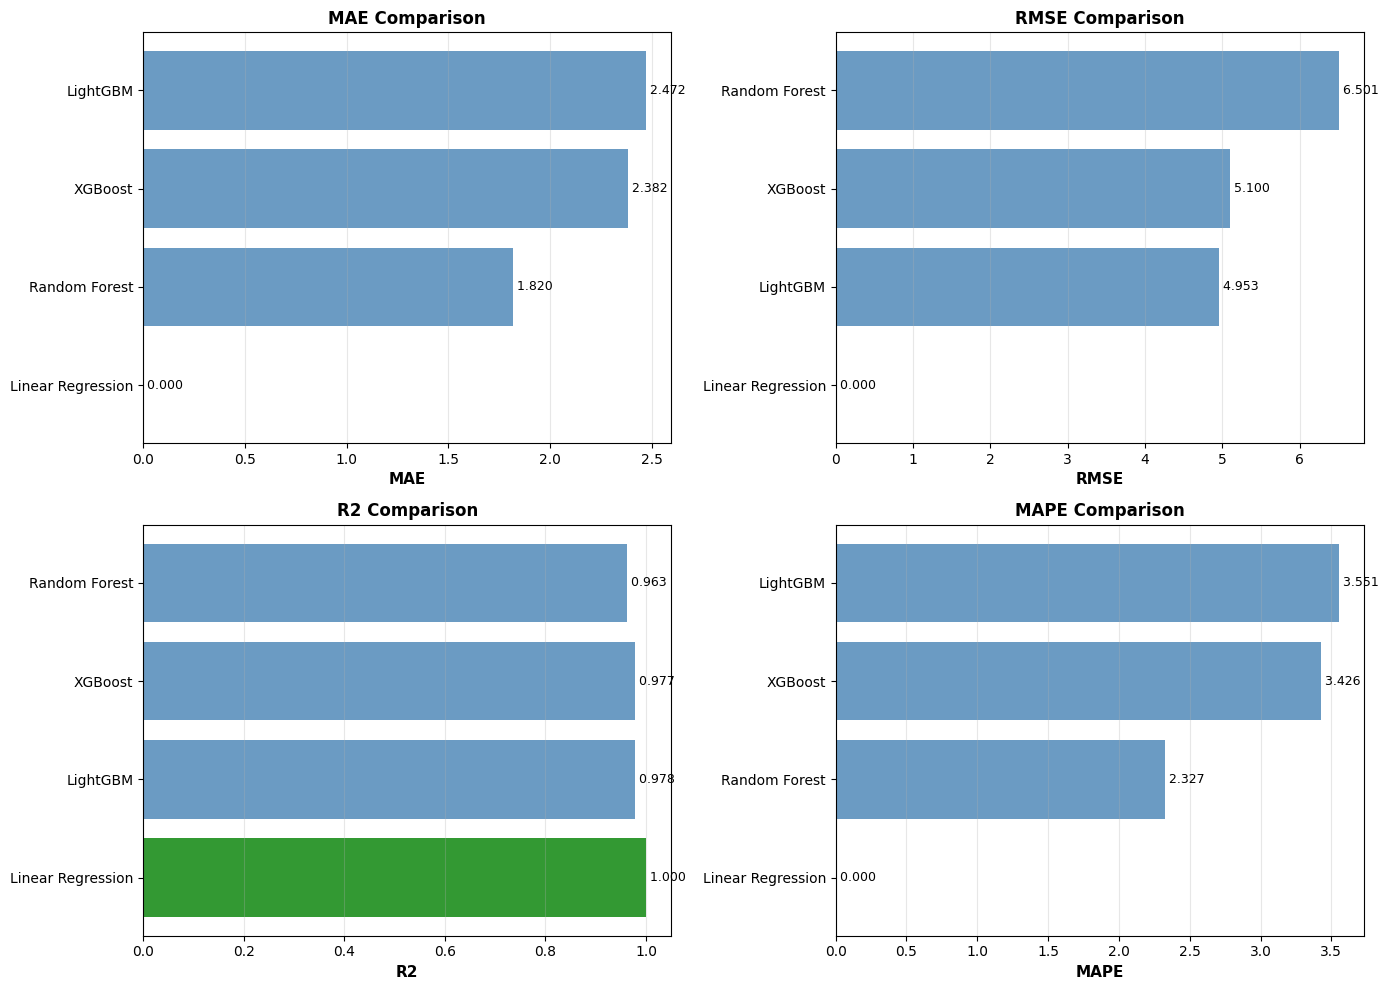

Model comparison plot saved as 'model_comparison.png'


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['MAE', 'RMSE', 'R2', 'MAPE']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    sorted_df = results_df.sort_values(metric, ascending=(metric != 'R2'))
    colors = ['green' if i == 0 else 'steelblue' for i in range(len(sorted_df))]
    ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, alpha=0.8)
    ax.set_xlabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for i, (_, row) in enumerate(sorted_df.iterrows()):
        ax.text(row[metric], i, f' {row[metric]:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Model comparison plot saved as 'model_comparison.png'")

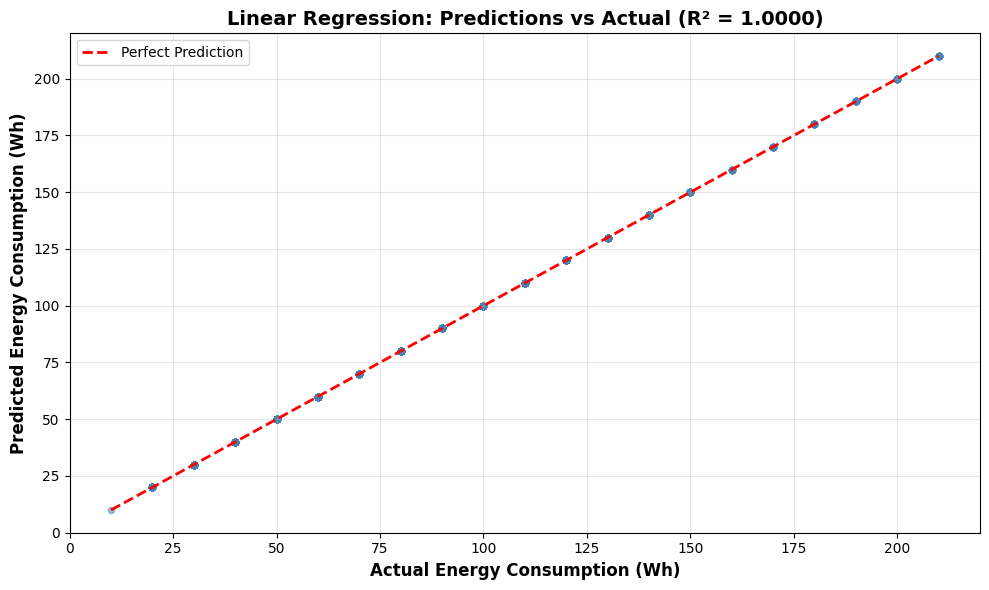

Predictions plot saved as 'predictions_vs_actual.png'


In [17]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, y_pred_best, alpha=0.5, s=20, color='steelblue')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
r2 = r2_score(y_test, y_pred_best)
ax.set_xlabel('Actual Energy Consumption (Wh)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Energy Consumption (Wh)', fontsize=12, fontweight='bold')
ax.set_title(f'{best_model_name}: Predictions vs Actual (R² = {r2:.4f})', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()
print("Predictions plot saved as 'predictions_vs_actual.png'")

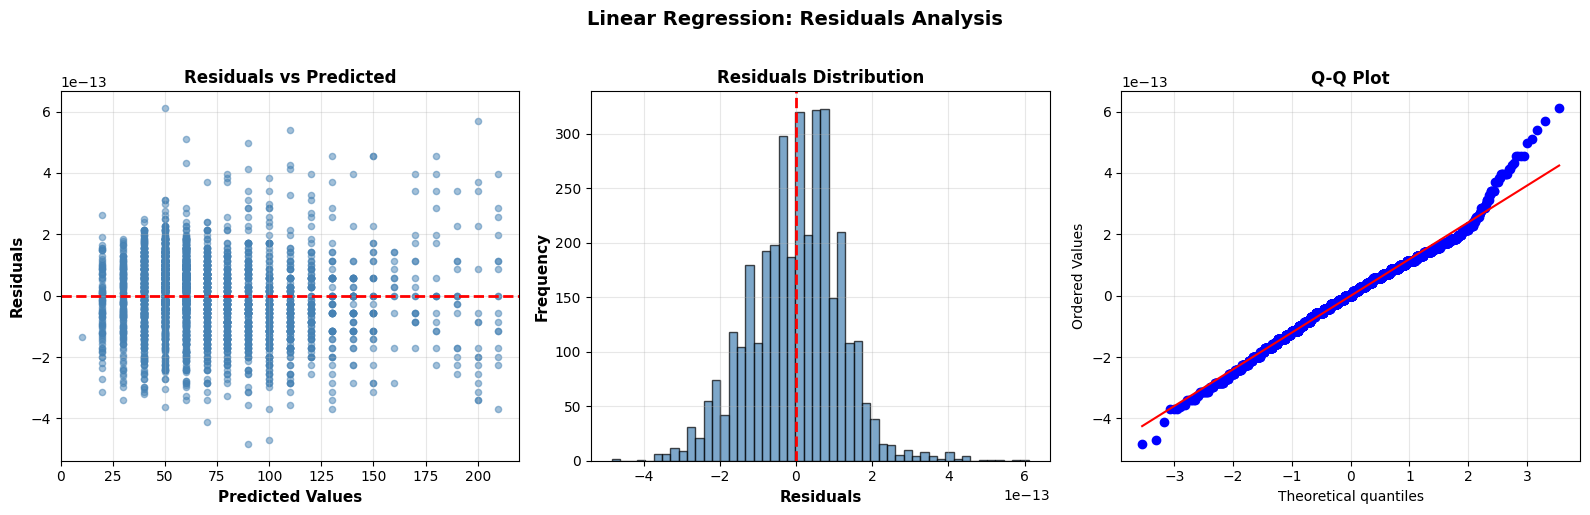

Residuals plot saved as 'residuals_analysis.png'


In [18]:
residuals = y_test - y_pred_best
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[1].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Residuals Distribution', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)
fig.suptitle(f'{best_model_name}: Residuals Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Residuals plot saved as 'residuals_analysis.png'")


Feature Importance Analysis:

Linear Regression does not support feature importance.
Feature importance is only available for tree-based models:
  - Random Forest
  - XGBoost
  - LightGBM

To get feature importance, you can check the other tree-based models:

Random Forest Feature Importance:
------------------------------------------------------------
                  feature  importance
Appliances_rolling_mean_3    0.711288
 Appliances_rolling_min_3    0.147007
         Appliances_lag_2    0.053081
         Appliances_lag_1    0.029190
 Appliances_rolling_max_3    0.025406
 Appliances_rolling_std_3    0.016717
         Appliances_lag_3    0.001896
 Appliances_rolling_std_6    0.000727
 Appliances_rolling_max_6    0.000560
                   RH_out    0.000533


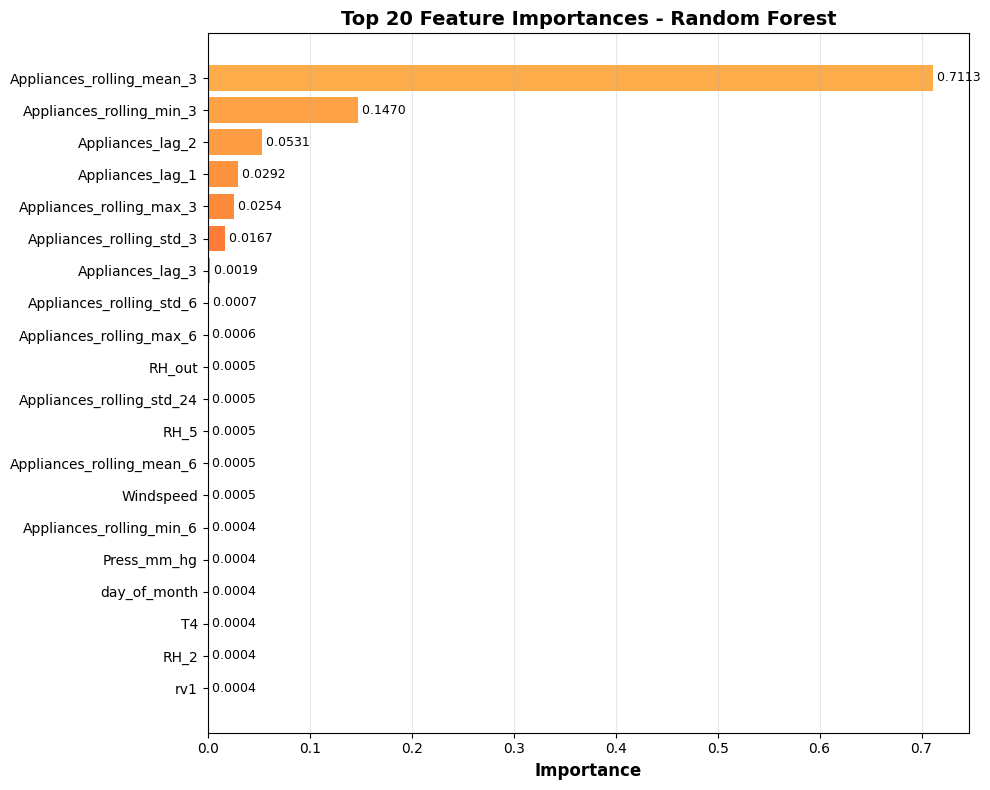

Feature importance plot saved as 'feature_importance_Random_Forest.png'
Feature importance saved as 'feature_importance_Random_Forest.csv'


XGBoost Feature Importance:
------------------------------------------------------------
                  feature  importance
 Appliances_rolling_max_3    0.334892
Appliances_rolling_mean_3    0.218582
 Appliances_rolling_min_3    0.131961
         Appliances_lag_2    0.028513
 Appliances_rolling_min_6    0.022663
             is_afternoon    0.020756
         Appliances_lag_1    0.019370
 Appliances_rolling_std_3    0.018935
Appliances_rolling_min_12    0.017905
         Appliances_lag_3    0.012554


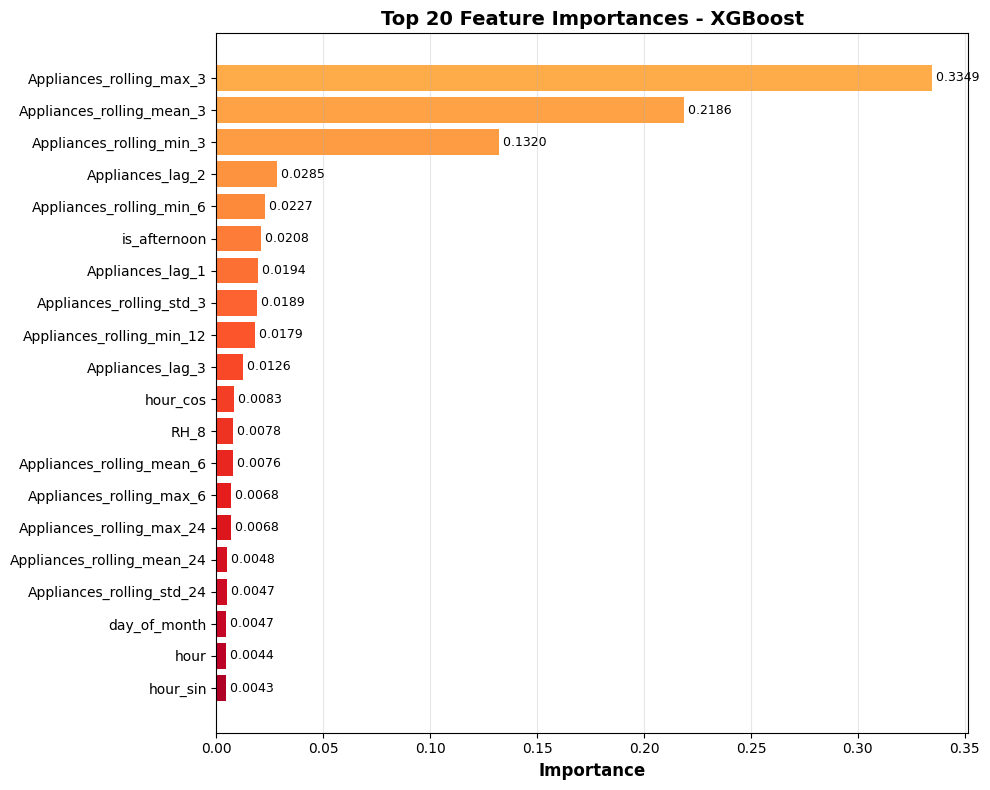

Feature importance plot saved as 'feature_importance_XGBoost.png'
Feature importance saved as 'feature_importance_XGBoost.csv'


LightGBM Feature Importance:
------------------------------------------------------------
                   feature  importance
 Appliances_rolling_mean_3         521
          Appliances_lag_1         466
          Appliances_lag_2         438
  Appliances_rolling_min_3         247
  Appliances_rolling_std_3         212
  Appliances_rolling_max_3         212
          Appliances_lag_3          77
 Appliances_rolling_mean_6          76
  Appliances_rolling_min_6          36
Appliances_rolling_mean_24          27


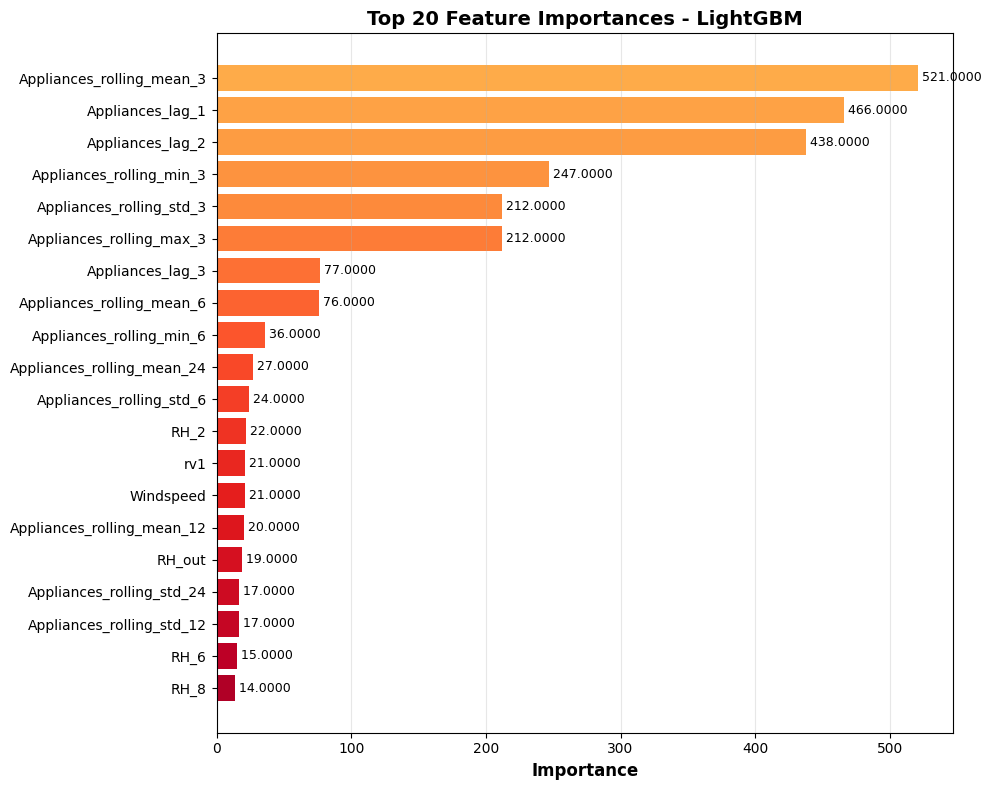

Feature importance plot saved as 'feature_importance_LightGBM.png'
Feature importance saved as 'feature_importance_LightGBM.csv'



In [21]:
print("\nFeature Importance Analysis:")
print("="*60)
if best_model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': X_train_scaled.columns,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    print(f"\nTop 20 Features for {best_model_name}:")
    print("="*60)
    print(feature_importance_df.head(20).to_string(index=False))
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance_df.head(20)
    colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_features)))
    bars = ax.barh(range(len(top_features)), top_features['importance'], color=colors)
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Top 20 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for i, (_, row) in enumerate(top_features.iterrows()):
        ax.text(row['importance'], i, f' {row["importance"]:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("\nFeature importance plot saved as 'feature_importance.png'")
    feature_importance_df.to_csv('feature_importance.csv', index=False)
    print("Feature importance saved as 'feature_importance.csv'")
else:
    print(f"\n{best_model_name} does not support feature importance.")
    print("Feature importance is only available for tree-based models:")
    print("  - Random Forest")
    print("  - XGBoost")
    print("  - LightGBM")
    print("\nTo get feature importance, you can check the other tree-based models:")
    for name in ['Random Forest', 'XGBoost', 'LightGBM']:
        if name in trained_models:
            print(f"\n{name} Feature Importance:")
            print("-"*60)
            model = trained_models[name]
            importances = model.feature_importances_
            feature_importance_df = pd.DataFrame({
                'feature': X_train_scaled.columns,
                'importance': importances
            }).sort_values('importance', ascending=False).reset_index(drop=True)
            print(feature_importance_df.head(10).to_string(index=False))
            fig, ax = plt.subplots(figsize=(10, 8))
            top_features = feature_importance_df.head(20)
            colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_features)))
            bars = ax.barh(range(len(top_features)), top_features['importance'], color=colors)
            ax.set_yticks(range(len(top_features)))
            ax.set_yticklabels(top_features['feature'])
            ax.invert_yaxis()
            ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
            ax.set_title(f'Top 20 Feature Importances - {name}', fontsize=14, fontweight='bold')
            ax.grid(axis='x', alpha=0.3)
            for i, (_, row) in enumerate(top_features.iterrows()):
                ax.text(row['importance'], i, f' {row["importance"]:.4f}', va='center', fontsize=9)
            plt.tight_layout()
            plt.savefig(f'feature_importance_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
            plt.show()
            print(f"Feature importance plot saved as 'feature_importance_{name.replace(' ', '_')}.png'")
            feature_importance_df.to_csv(f'feature_importance_{name.replace(" ", "_")}.csv', index=False)
            print(f"Feature importance saved as 'feature_importance_{name.replace(' ', '_')}.csv'\n")